In [1]:
%pip install pandas numpy scikit-learn openpyxl

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
df = pd.read_excel("/Users/sainishanth/Desktop/ML/Test/training_data.xlsx")

print(df.head())
print(df.info())
df.describe()

     Batch_ID  Time_Minutes  Temperature_C  Pressure_Bar  Humidity_Percent  \
0  Batch_T056           117      32.048530      0.922644         36.404677   
1  Batch_T058           193      22.290754      1.181892         44.617734   
2  Batch_T028           140      30.859124      1.024139         27.664439   
3  Batch_T035             8      26.167542      1.258832         45.640769   
4  Batch_T036           109      29.234271      0.873294         34.450768   

   Motor_Speed_RPM  Compression_Force_kN  Flow_Rate_LPM  Power_Consumption_kW  \
0       200.782892              0.000000              0             12.451017   
1         0.000000              0.000000              0              6.319297   
2        45.731001             14.055176              0             46.011500   
3         0.000000              0.000000              0              3.191840   
4       210.084864              0.000000              0             15.272412   

   Vibration_mm_s  Phase_Compression  Phase_

,Time_Minutes,Temperature_C,Pressure_Bar,Humidity_Percent,Motor_Speed_RPM,Compression_Force_kN,Flow_Rate_LPM,Power_Consumption_kW,Vibration_mm_s
count,7286.000000,7286.000000,7286.000000,7286.000000,7286.000000,7286.000000,7286.0,7286.000000,7286.000000
mean,136.782048,27.028851,0.999135,37.007421,49.205435,5.166053,0.0,23.265775,3.001384
std,70.018736,2.353128,0.099441,7.337035,64.206463,6.247164,0.0,19.971001,2.428547
min,0.000000,19.276826,0.675509,23.823369,0.000000,0.000000,0.0,0.375890,-0.062744
25%,97.000000,25.245004,0.932183,30.292735,0.000000,0.000000,0.0,4.764086,0.474257
50%,135.000000,27.040787,0.997425,34.720893,45.376878,0.000000,0.0,12.334007,3.086165
75%,193.000000,28.742084,1.066745,44.487337,53.419303,11.388561,0.0,43.987312,5.376331
max,284.000000,34.327077,1.289617,53.759491,246.376153,19.864406,0.0,70.587999,8.028482


In [4]:
df = df.drop(columns=['Batch_ID','Time_Minutes'])

In [5]:
df = pd.get_dummies(df, columns=['Phase'])

KeyError: "None of [Index(['Phase'], dtype='str')] are in the [columns]"

In [6]:
X = df.drop(columns=['Power_Consumption_kW'])
y = df['Power_Consumption_kW']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [9]:
predictions = model.predict(X_test)

In [10]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 2.652833716132299
RMSE: 4.117035365148716


In [11]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, predictions)

print("R2 Score:", r2)

R2 Score: 0.9573620334977097



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


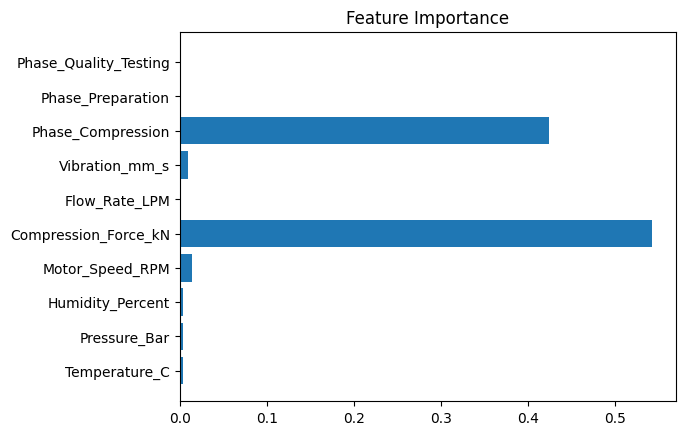

In [12]:
%pip install matplotlib
import matplotlib.pyplot as plt

importance = model.feature_importances_
features = X.columns

plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()

In [13]:
import joblib

joblib.dump(model, "energy_model.pkl",compress=3)

['energy_model.pkl']

In [14]:
df["Yield"] = (
    95
    - abs(df["Temperature_C"] - 140) * 0.05
    - abs(df["Pressure_Bar"] - 1.0) * 2
    - df["Vibration_mm_s"] * 0.3
    + np.random.normal(0, 1, len(df))
)

In [15]:
df["Yield"] = df["Yield"].clip(85, 98)

In [16]:
df["Quality"] = (
    90
    - df["Vibration_mm_s"] * 0.5
    + df["Compression_Force_kN"] * 0.02
    - abs(df["Humidity_Percent"] - 40) * 0.1
    + np.random.normal(0, 1, len(df))
)

df["Quality"] = df["Quality"].clip(80, 96)

In [ ]:
# prepare dataset for yield model
X_yield = df.drop(columns=["Yield"])
y_yield = df["Yield"]

X_train_y, X_test_y, y_train_y, y_test_y = train_test_split(
    X_yield, y_yield, test_size=0.2, random_state=42
)

In [ ]:
yield_model = RandomForestRegressor(n_estimators=200)
yield_model.fit(X_train_y, y_train_y)

# evaluate yield model on its own test split
yield_pred = yield_model.predict(X_test_y)
r2_yield = r2_score(y_test_y, yield_pred)
print("Yield model R2 Score:", r2_yield)

R2 Score: 0.9573620334977097


In [ ]:
# prepare dataset for quality model
X_quality = df.drop(columns=["Quality"])
y_quality = df["Quality"]

X_train_q, X_test_q, y_train_q, y_test_q = train_test_split(
    X_quality, y_quality, test_size=0.2, random_state=42
)

In [ ]:
quality_model = RandomForestRegressor(n_estimators=200)
quality_model.fit(X_train_q, y_train_q)

# evaluate quality model on its own test split
quality_pred = quality_model.predict(X_test_q)
r2_quality = r2_score(y_test_q, quality_pred)
print("Quality model R2 Score:", r2_quality)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [21]:
import joblib

joblib.dump(yield_model, "yield_model.pkl",compress=3)
joblib.dump(quality_model, "quality_model.pkl",compress=3)

['quality_model.pkl']

In [22]:
energy_model = joblib.load("energy_model.pkl")
yield_model = joblib.load("yield_model.pkl")
quality_model = joblib.load("quality_model.pkl")

In [23]:
def calculate_carbon(energy):
    emission_factor = 0.82
    carbon = energy * emission_factor
    return carbon

In [24]:
predicted_energy = 420
carbon = calculate_carbon(predicted_energy)

print("Carbon Emission:", carbon)

Carbon Emission: 344.4


In [ ]:
from sklearn.metrics import r2_score
yield_predictions = yield_model.predict(X_test_y)
r2 = r2_score(y_test_y, yield_predictions)
print("Yield test R2 Score:", r2)

R2 Score: 0.9562189897889866


In [ ]:
from sklearn.metrics import r2_score
quality_predictions = quality_model.predict(X_test_q)
r2 = r2_score(y_test_q, quality_predictions)
print("Quality test R2 Score:", r2)

R2 Score: 0.9562300919416884
